Nombres y apellidos: Alfonso Íñiguez Cortés \
Correo: aic35@alu.ua.es \
Grupo: 3

# Grafos sobre la vida real 

Vamos a importar las librerías que vamos a necesitar a lo largo de esta práctica

In [7]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

## 1. Commute Time Embedding

En las anteiores prácticas hemos estudiado como realizar caminos aleatorios sobre grafos y como usarlos para aprender embeddings de nodos con alogoritmos como `Node2Vec`. En esta sección vamos a estudiar otro enfoque diferente basado en **teoría espectral** : `Commute Time Embedding`

### 1.1 ¿Qué es el Commute Time Embedding?

Dado un grafo conexo dirigido $G = (V, E)$: el commute time embedding entre dos nodos `a` y `b` es el número que se espera de pasos que un camino aleatorio necesita recorrer desde `a` hasta `v` y de vuelta `a`. 

El **tiempo de golpe** son los pasos espetados para llegar desde `a` hasta `b`, definido por la siguiente expresión:
$$ CT(a,b) = H(a,b) + H(b, a) $$

Donde:
- $H(a,b)$: pasos para llegar desde `a` hasta `b` (y viceversa para $H(b,a)$)
- $CT(a,b)$: pasos totales de ida y vuelta

Esta forma de medición es más "rica" que la distancia mínima tradicional puesto que tienen en cuanta todos los caminos posibles y no  solo el más corto

**Relación con el laplaciano**
Podemos calcular este tiempo de desplazamiento si utilizamos la pseudoinversa del laplaciano del grafo:
$$ CT(u,v) = vol(G) * (Laa + Lbb - 2Lab) $$

Donde:
- L: psuedoinversa de Moore-Penrose (laplaciano)
- vol(G): representa el volumen del grafo -> suma de todos los grados. Viene dado por la fórmula:
$$ vol(G) = \sum_i(di) $$

Gracias a esta expresión, podemos relacionar directamente la estructura global del grafo con distancias entre nodos

### 1.2 ¿Por qué es útil el Commute Time?

Esta técnica posee varias ventajas notables e importantes:
- Tiene en cuenta la conectividad del grafo
- Está relacionada con `Random Walk` (caminos aleatorios)
- Permite representar nodos en espacios euclidianos
- Facilita detectar comumidades y grupos

Los nodos muy conectados entre sí van a tener un tiempo de desplazamiento pequeño, mientras que los poco conectados (aljeados) su tiempo de desplazamiento será mucho mayor

### 1.3 Laplaciano del grafo

Para poder calcular los embeddings, primero tenemos que construir el **laplaciano** de un grafo. Este viene definido por la siguiente fórmula:
$$ L = D - A $$

Donde:
- D: matriz diagonal de grafos
- A: matriz adyacencia
La matriz diagonal conotiene el grado de cada nodo: $D_(ii) = d_i$

El laplaciano cuenta con varias propiedades importantes:
- Es **simétrico**: sirve para utilizar algoritmos numéricamente estables (autovectores y autovalores)
- Es semidefinido positivo: todos los autovalores son >= a cero
- El menor autovalor **siempre** es cero:
$$ 0 = \gamma_i < \gamma_2 < ... < \gamma_n $$
El vector propio asociado a $\gamma_1$ es el vector cte
- El valor de Fielder: el segundo autovalor más pequeó ($\gamma_2$) mide qué tan conectado está el grafo:
-> Si $\gamma_2$ pequeño -> grafo tiene comunidades débiles \
-> Si $\gamma_2$ grande -> grafo muy conectado (comunidades fuertes)

### 1.4 Laplaciano -> Embeddings

El `Commmute Time Embedding` utiliza la descomposición espectral del laplaciano para constuir vectores asociados a cada nodo.

Representación de un nodo:
$$ z_i = (1/\sqrt(\gamma_2)*\alpha_2(i), 1/\sqrt(\gamma_3)*\alpha_3(i), ..., 1/\sqrt(\gamma_(k+1))*\alpha_(k+1)(i)) $$

Donde:
- $\alpha_j$ : autovectores
- $\gamma_j$ : autovalores
- $k$ : nº dimensiones

Al final, cada nodo queda representado por un vector numérico

##### Propiedad 
Distancia euclidiana entre embeddings aproxima el commute time:
$$ (|z_i - z_j|)^2 = CT(i, j) $$
Esta expresión significa que los nodos cercanos en el embedding estarán cerca a nivel estructural (del grafo)

### 1.5 Derivación paso a paso

**PASOS**
1. **Construir laplaciano**
$$ L = D - A $$

2. **Descomposición espectral**
Calculamos (del laplaciano):
- Autovalores ($\gamma_i$)
- Autovectores ($\alpha_i$)

3. **Seleccionar autovectores útiles**

Se elimina:
- $\alpha_1$ ya que corresponde con el autovalor 0 y no nos da información estructural 

Después:
- Se seleccionan los siguientes _K_ autovectores más importantes

4. **Escalado**
Cada autovector se divide por la expresión:
$$ 1/\sqrt{\gamma_j} $$
Esto hace que los autovalores pequeños tengan más importancia

5. **Construcción embedding**

Se crea la matriz:
$$ Z = [\gamma_2 | \gamma_3 |...| \gamma_(k+1)] $$
donde cada fila representa un nodo del grafo

### 1.3 Fragmento de código

Vamos a desglosar el siguente fragmento de código en bloques y vamos a explicar cada uno de ellos con el objetivo de entender el funcionamiento interno del `Commute Time Embedding`

In [2]:
import numpy as np
import networkx as nx
from scipy.linalg import eigh  # eigh for symmetric matrices (more stable than eig)

def commute_time_embedding(G, k):
    """
    Compute the Commute Time Embedding of graph G in k dimensions.

    Parameters
    ----------
    G : networkx.Graph
        An undirected connected graph.
    k : int
        Number of embedding dimensions (number of non-trivial eigenvectors to use).

    Returns
    -------
    Z : np.ndarray of shape (n_nodes, k)
        Embedding matrix. Row i is the embedding of node i.
        The squared Euclidean distance ||Z[i] - Z[j]||^2 equals the commute
        time CT(i, j).
    """
    # Step 1: Build the Laplacian
    L = nx.laplacian_matrix(G).toarray().astype(float)
    n = L.shape[0]

    # Step 2: Eigendecomposition — eigh returns eigenvalues in ascending order
    # We only need the first k+1 eigenpairs (0-indexed: 0 to k)
    eigenvalues, eigenvectors = eigh(L, subset_by_index=[0, k])
    # eigenvalues[j] = lambda_j, eigenvectors[:, j] = phi_j

    # Step 3: Skip lambda_0 = 0 (index 0); keep indices 1 to k
    # These correspond to lambda_2, ..., lambda_{k+1} in 1-indexed notation
    lam = eigenvalues[1:]        # shape (k,)
    Phi = eigenvectors[:, 1:]    # shape (n, k)

    # Safety check: all selected eigenvalues must be strictly positive
    if np.any(lam <= 1e-10):
        raise ValueError(
            "Graph appears to be disconnected or k is too large. "
            "All non-trivial eigenvalues must be strictly positive."
        )

    # Step 4: Scale each eigenvector by 1/sqrt(lambda_j)
    # Broadcasting: divide each column j of Phi by sqrt(lam[j])
    Z = Phi / np.sqrt(lam)   # shape (n, k)

    return Z

##### **Bloque 1** -> Construcción del laplaciano
---
Este bloque sirve para construir el laplaciano, que es el primer paso de este algoritmo

- **L**: calcula el laplaciano usando la fórmula: $L = D - A$
- **n**: obtenemos el número de filas de la matriz. Este valor representa el número de nodos del grafo (cada nodo es una fila)


##### **Bloque 2** -> Descomposicion espectral
---
En este bloque calculamos los autovalores y autovectores del laplaciano calculado en el primer bloque. Ambos se calculan con la función `eigh()`
- **eigenvalues**: autovalores 
- **eigenvectores**: autovectores


##### **Bloque 3** -> Eliminar autovector "trivial"
---
En este bloque eliminamos el primer autovector y autovalor (puesto que no aportan información estructural)
- **lam**: seleccionamos todos los autovalores menos el primero ```python [1:] ``` ya que el primero corresponde al vector constante (explicado en las anteriores secciones)
- **Phi**: seleccionamos todas las filas. En cuanto a las columnas, selccionamos desde la primera columna hasta el final, eliminando así el primer autovector


##### **_paso intermedio_** -> Comprobación seguridad
---
En este paso comprobamos:
- Grafo sea conexo 
- Autovalores sean válidos (para ser inválido: (0, cercano a 0))
Esta comprobación sirve para comprobar que el grafo no sea desconectado o existan problemas numéricos


##### **Bloque 3** -> Escalado de autovectores
---
En este bloque construimos el embedding final

- Calculamos $\sqrt(\gamma_j)$ para cada autovalor
- Dividiamos cada columna del autovector por el valor calculado (arriba) 

Luego:
- **Z**: matriz embedding (cada fila: nodo como vector)


### 1.7 Aplicación práctica

Ahora que sabemos como funciona el algoritmo a nivel de código, vamos a aplicarlo sobre un grafo sintético:

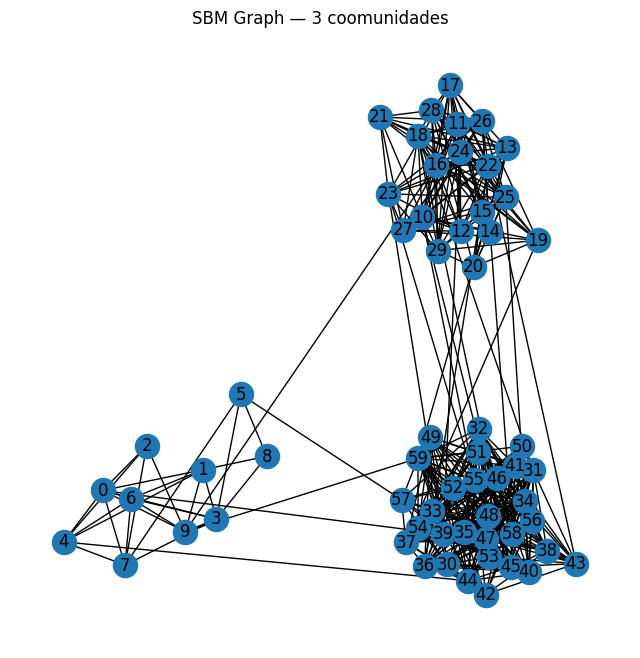

Embedding matrix shape: (60, 2)
Embedding of node 3: [-0.37134038 -0.03214285]
Embedding of node 5: [ 0.13145233 -0.18676579]
Embedding of node 22: [0.05767251 0.12535408]


In [13]:
# -Construimos el grafo
G = nx.stochastic_block_model(
    [10, 20, 30],
    [
        [0.6,  0.02, 0.02],
        [0.02, 0.6,  0.02],
        [0.02, 0.02, 0.6 ]
    ],
    seed=99
)

# Vamos a visualizar el grafo
plt.figure(figsize=(8, 8))
plt.title("SBM Graph — 3 coomunidades")
nx.draw(G, pos, with_labels=True, node_size=300)
plt.show()

# Commute time embedding
k = 2  # Usamos 2 dimensiones para una visualización sencilla
Z = commute_time_embedding(G, k=k)

print(f"Embedding matrix shape: {Z.shape}")  # (60, 2)
print(f"Embedding of node 3: {Z[0]}")
print(f"Embedding of node 5: {Z[20]}")
print(f"Embedding of node 22: {Z[40]}")

### 1.8 Visualización de los embeddings